In [80]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from tensorflow.keras import layers, models

In [81]:
DATA_DIR = Path(r"E:/edu/4-2/ETE4215/LAB/data/3Xray_Limited")
IMG_SIZE = (254, 254)
BATCH_SIZE = 16
SEED = 16

print("Current working directory:", os.getcwd())
print("Dataset exists:", DATA_DIR.exists())

Current working directory: C:\Users\USER
Dataset exists: True


In [82]:
records = []

for class_dir in sorted(DATA_DIR.iterdir()):
    if class_dir.is_dir():
        for image_path in sorted(class_dir.glob("*.png")):
            records.append({"filepath": str(image_path), "label_name": class_dir.name})

df = pd.DataFrame(records)
class_names = sorted(df["label_name"].unique())
class_to_index = {name: idx for idx, name in enumerate(class_names)}
df["label"] = df["label_name"].map(class_to_index)

df.head()

,filepath,label_name,label
0,E:\edu\4-2\ETE4215\LAB\data\3Xray_Limited\ELBO...,ELBOW,0
1,E:\edu\4-2\ETE4215\LAB\data\3Xray_Limited\ELBO...,ELBOW,0
2,E:\edu\4-2\ETE4215\LAB\data\3Xray_Limited\ELBO...,ELBOW,0
3,E:\edu\4-2\ETE4215\LAB\data\3Xray_Limited\ELBO...,ELBOW,0
4,E:\edu\4-2\ETE4215\LAB\data\3Xray_Limited\ELBO...,ELBOW,0


In [83]:
class_distribution = df["label_name"].value_counts().sort_index()
class_distribution

label_name
ELBOW    54
FOOT     53
KNEE     54
Name: count, dtype: int64

TypeError: 'str' object is not callable

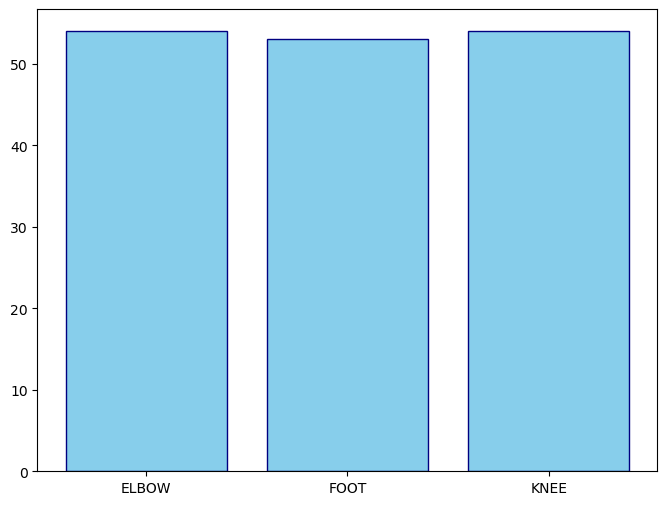

In [84]:
plt.figure(figsize=(8, 6))
bars = plt.bar(class_distribution.index, class_distribution.values, color='skyblue', edgecolor='navy')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=11)

plt.title('Distribution of Classes')
plt.xlabel('X-Ray Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(DATA_DIR / 'class_distribution.pdf')
plt.show()

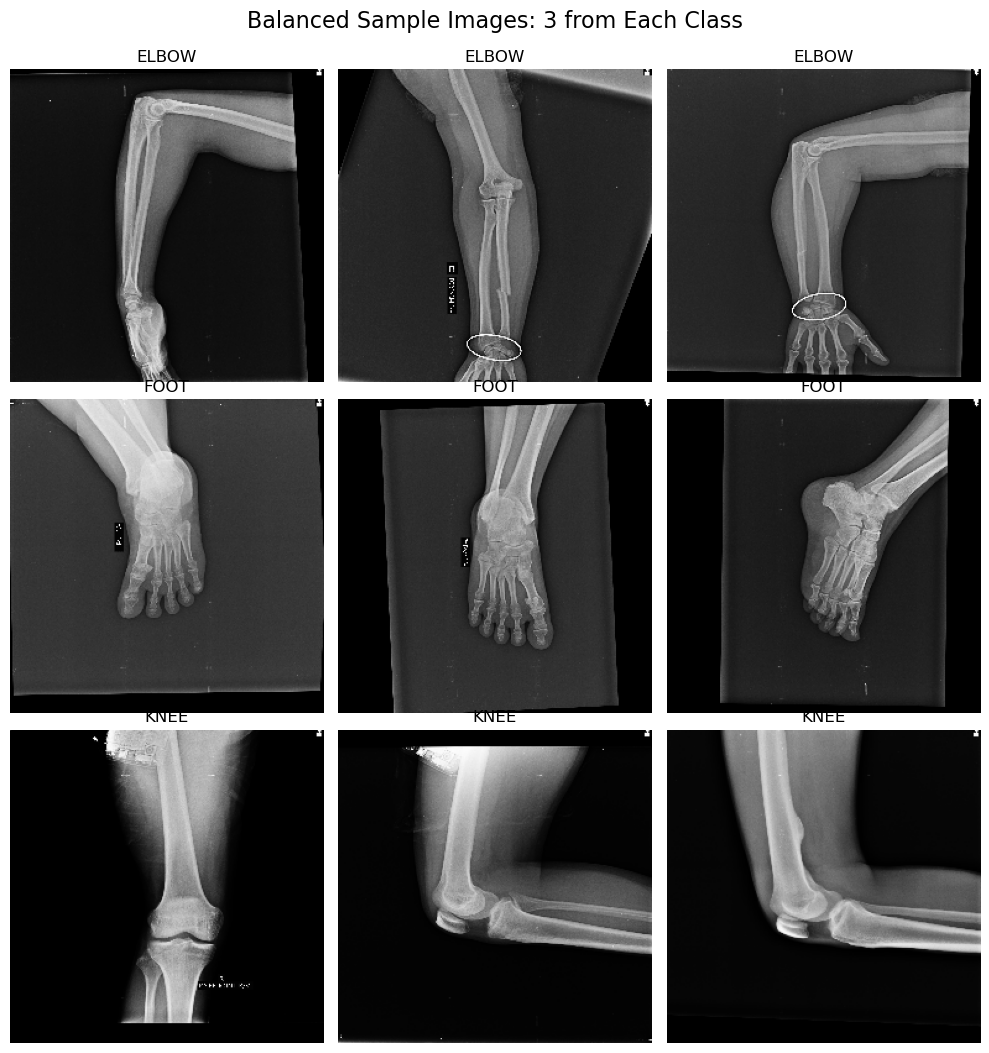

In [95]:
sample_df = df.groupby('label_name', group_keys=False).tail(3)

plt.figure(figsize=(10, 11))
plt.suptitle('Balanced Sample Images: 3 from Each Class', fontsize=16)
for i, (_, row) in enumerate(sample_df.iterrows()):
    ax = plt.subplot(3, 3, i + 1)
    image = tf.keras.utils.load_img(row['filepath'], target_size=IMG_SIZE)
    plt.imshow(image)
    plt.title(row['label_name'])
    plt.tight_layout()
    plt.axis('off')
plt.tight_layout()
plt.savefig(DATA_DIR / 'sample_images_balanced.pdf')
plt.show()

In [96]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df['label_name']
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [99]:
count_table = pd.DataFrame({
    'Full Dataset': df['label_name'].value_counts().sort_index(),
    'Training Data': train_df['label_name'].value_counts().sort_index(),
    'Test Data': test_df['label_name'].value_counts().sort_index()
}).fillna(0).astype("int64")

count_table.loc['Total'] = count_table.sum()
count_table

,Full Dataset,Training Data,Test Data
label_name,,,
ELBOW,54,43,11
FOOT,53,42,11
KNEE,54,43,11
Total,161,128,33


In [100]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


In [101]:
train_ds = tf.data.Dataset.from_tensor_slices((train_df['filepath'].values, train_df['label'].values))
train_ds = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(len(train_df), seed=SEED).batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_df['filepath'].values, test_df['label'].values))
test_ds = test_ds.map(load_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [102]:
for images, labels in train_ds.take(1):
    print('Single image shape:', images[0].shape)
    print('Batch size:', len(images))
    print('Class names:', class_names)

Single image shape: (254, 254, 3)
Batch size: 16
Class names: ['ELBOW', 'FOOT', 'KNEE']


In [103]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(32, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

In [104]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 252, 252, 256)       │           7,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 126, 126, 256)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 124, 124, 256)       │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 62, 62, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 60, 60, 128)         │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 28, 28, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │       1,605,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,582,275 (9.85 MB)

 Trainable params: 2,582,275 (9.85 MB)

 Non-trainable params: 0 (0.00 B)

In [105]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 87s 10s/step - accuracy: 0.3438 - loss: 1.1459 - val_accuracy: 0.3333 - val_loss: 1.0902
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 78s 10s/step - accuracy: 0.4141 - loss: 1.0777 - val_accuracy: 0.4545 - val_loss: 1.0550
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 77s 10s/step - accuracy: 0.4688 - loss: 0.9896 - val_accuracy: 0.4242 - val_loss: 0.9758
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 76s 10s/step - accuracy: 0.4766 - loss: 0.9889 - val_accuracy: 0.4242 - val_loss: 1.0062
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 78s 10s/step - accuracy: 0.5625 - loss: 0.9320 - val_accuracy: 0.6061 - val_loss: 0.8536
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 77s 9s/step - accuracy: 0.6875 - loss: 0.7725 - val_accuracy: 0.4848 - val_loss: 0.8885
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 79s 10s/step - accuracy: 0.6953 - loss: 0.7884 - val_accuracy: 0.6667 - val_loss: 0.6824
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 78s 10s/step - accuracy: 0.7344 - loss: 0.6634 - val_accuracy: 0.6667 - val_loss: 0.6641
E

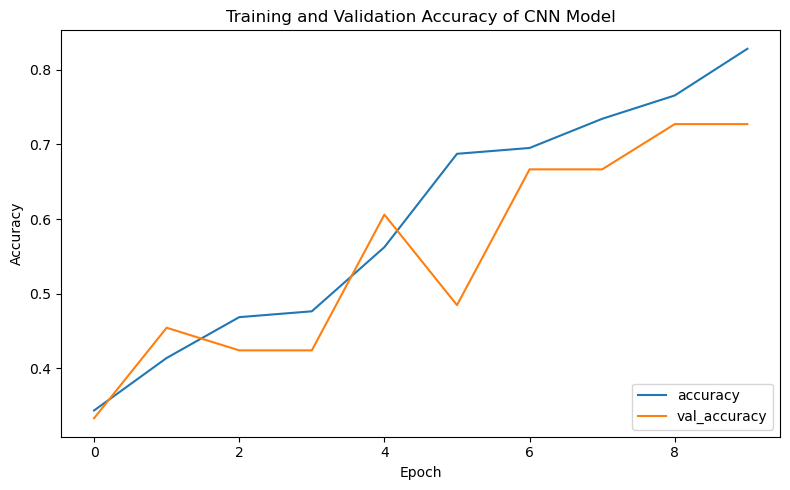

3/3 - 4s - 1s/step - accuracy: 0.7273 - loss: 0.5935


In [106]:
plt.figure(figsize=(8, 5))
plt.title('Training and Validation Accuracy of CNN Model')
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(DATA_DIR / 'cnn_accuracy.pdf')
plt.show()

test_loss, test_acc = model.evaluate(test_ds, verbose=2)

In [107]:
print('Test Accuracy:', test_acc)

Test Accuracy: 0.7272727489471436


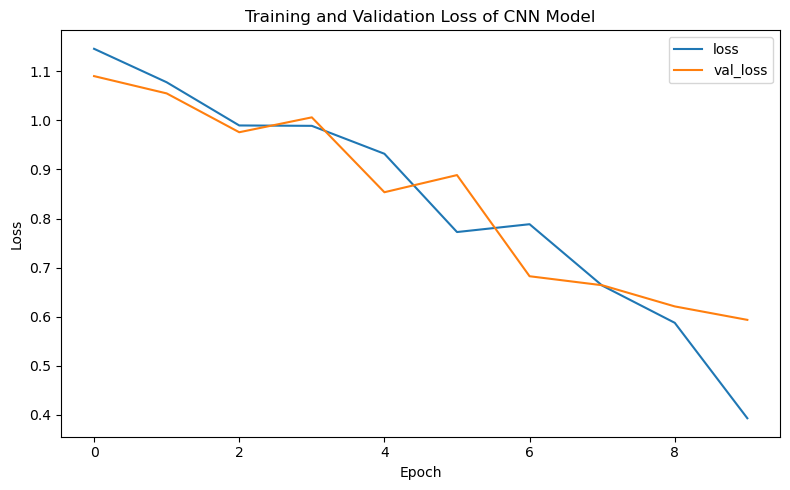

In [108]:
plt.figure(figsize=(8, 5))
plt.title('Training and Validation Loss of CNN Model')
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(DATA_DIR / 'cnn_loss.pdf')
plt.show()

In [115]:

y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
y_prob = model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

report = classification_report(y_true, y_pred, target_names=class_names)
cm = confusion_matrix(y_true, y_pred)
print(report)

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
              precision    recall  f1-score   support

       ELBOW       0.60      0.82      0.69        11
        FOOT       1.00      0.55      0.71        11
        KNEE       0.75      0.82      0.78        11

    accuracy                           0.73        33
   macro avg       0.78      0.73      0.73        33
weighted avg       0.78      0.73      0.73        33



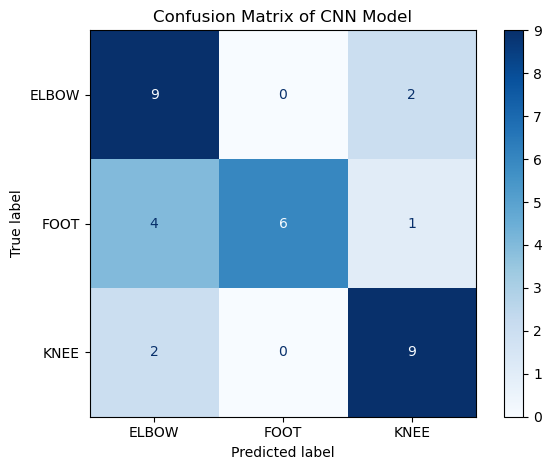

In [110]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix of CNN Model')
plt.tight_layout()
plt.savefig(DATA_DIR / 'cnn_confusion_matrix.pdf')
plt.show()

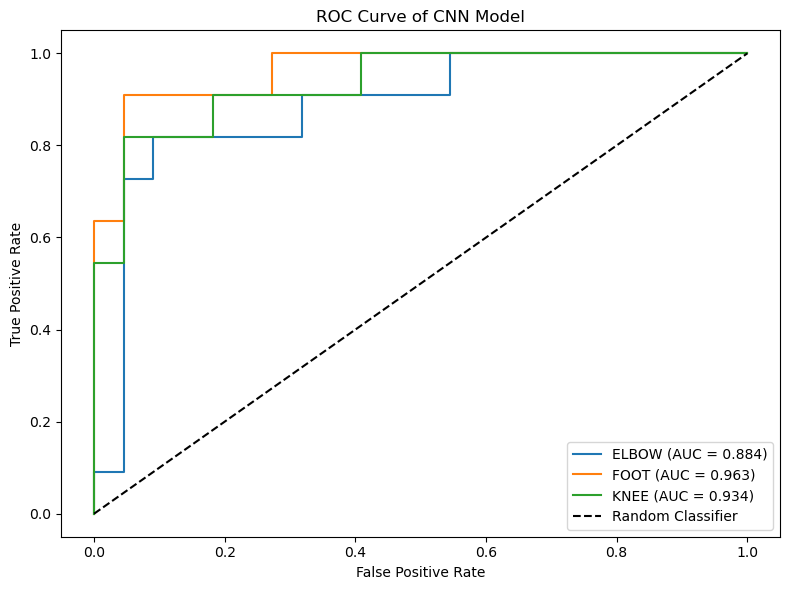

In [121]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('ROC Curve of CNN Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(DATA_DIR / 'cnn_roc_curve.pdf')
plt.show()

In [ ]:
# ml_dat=r'E:\edu\4-2\ETE4215\LAB\data\car_evaluation.tsv'
# df=pd.read_csv(ml_dat, sep='\t')
# #randomly shuffle the dataset and show 5 samples
# df = df.sample(frac=1, random_state=24).reset_index(drop=True)
# df.tail(10)

,buying_price,maintenance_costs,doors,seats,luggage_boot,safety,target
1718,1,0,1,1,2,1,2
1719,3,2,0,1,2,0,0
1720,3,0,1,0,1,2,0
1721,1,1,2,2,0,1,1
1722,3,2,1,1,0,1,0
1723,0,2,0,2,1,0,0
1724,3,0,0,2,0,1,0
1725,3,2,3,0,1,0,0
1726,1,3,1,0,2,2,0
1727,3,0,3,1,1,1,1
